# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [3]:
df_california = pd.read_csv('california_dataset.csv')

In [4]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

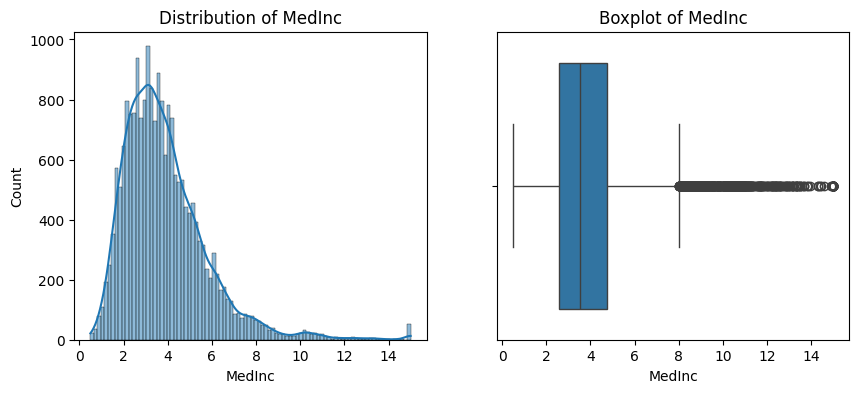

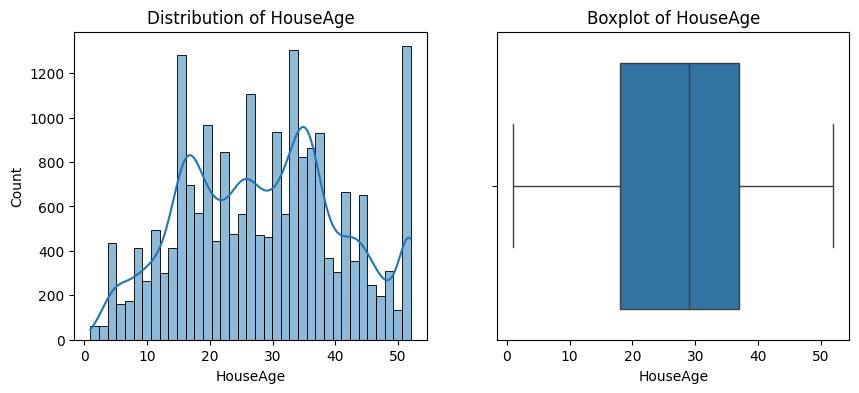

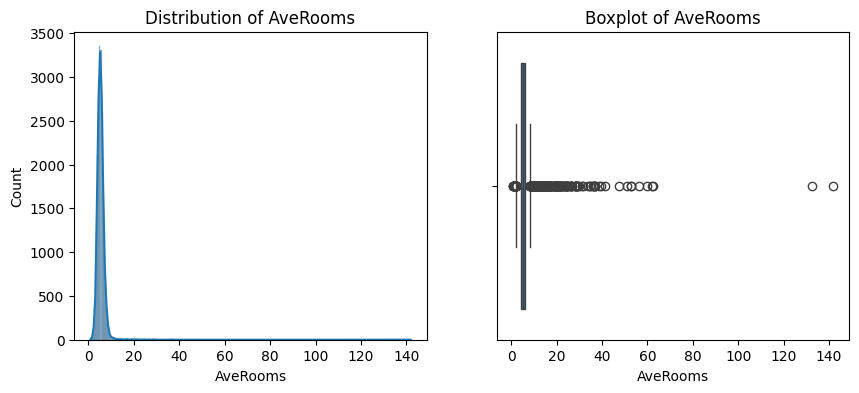

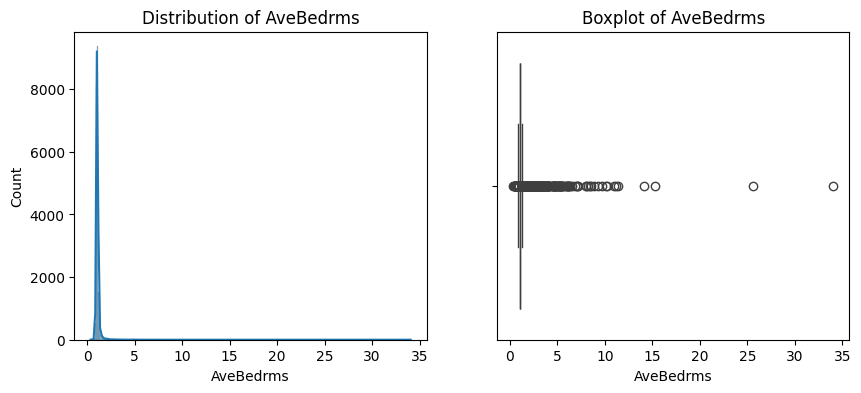

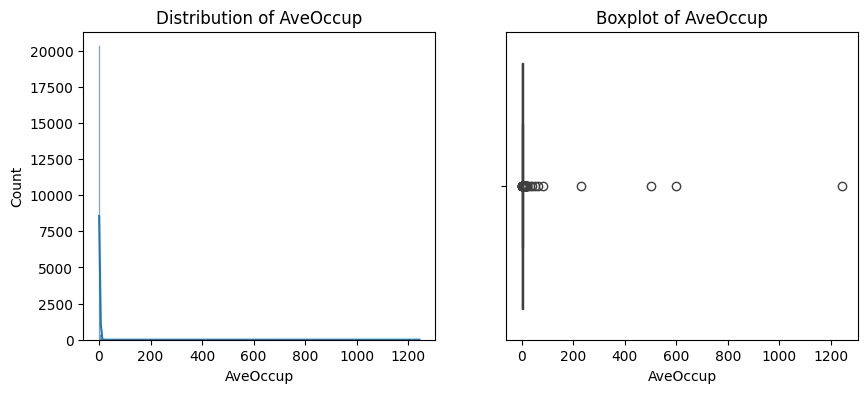

In [5]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek

columns = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for col in columns:
    
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    sns.histplot(df_california[col], kde=True)
    plt.title(f'Distribution of {col}')
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df_california[col])
    plt.title(f'Boxplot of {col}')
    
    plt.show() 

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [6]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali

col = 'AveOccup'

# menghitung Q1 dan Q3
Q1 = df_california[col].quantile(0.25)
Q3 = df_california[col].quantile(0.75)

# menghitung IQR
IQR = Q3 - Q1

# menentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# menghapus outlier
df_clean = df_california[(df_california[col] >= lower_bound) & (df_california[col] <= upper_bound)]




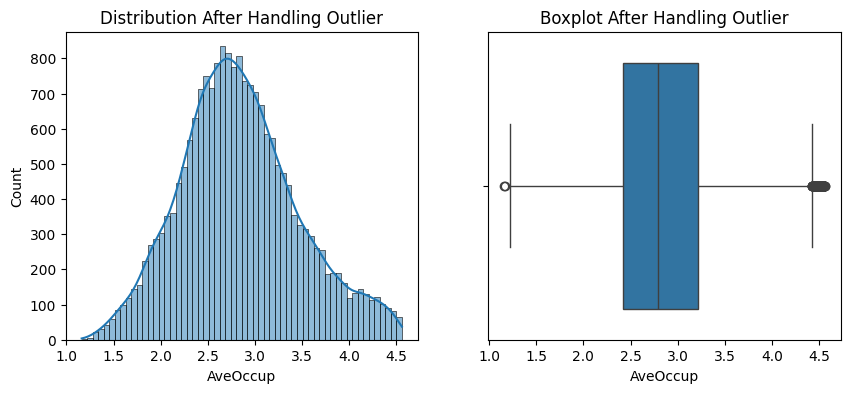

In [7]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_clean[col], kde=True)
plt.title("Distribution After Handling Outlier")

plt.subplot(1,2,2)
sns.boxplot(x=df_clean[col])
plt.title("Boxplot After Handling Outlier")

plt.show()


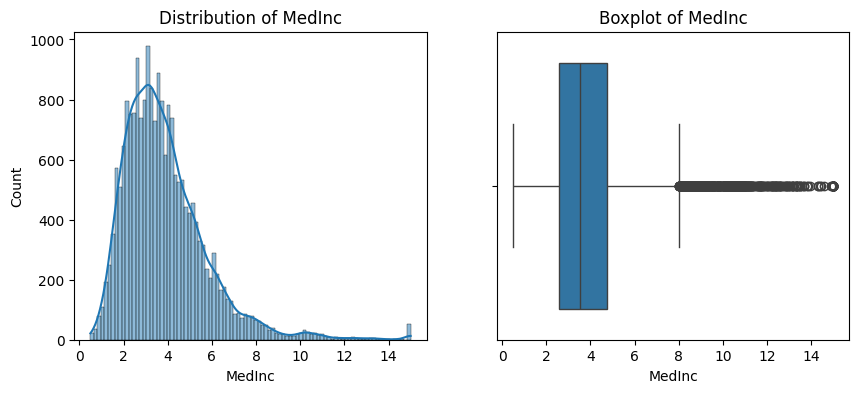

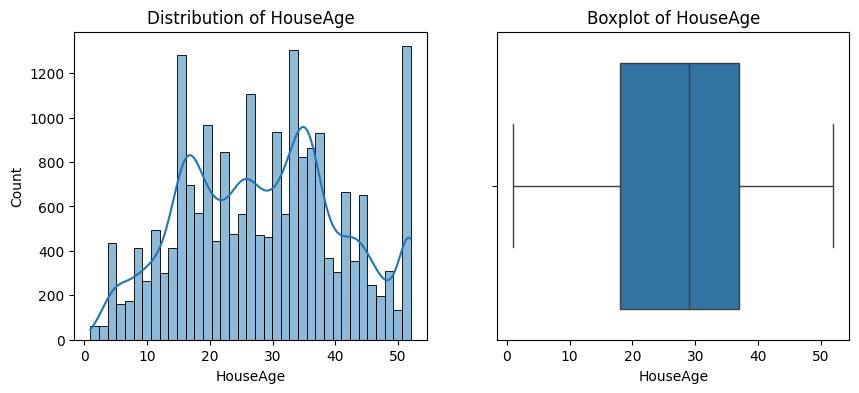

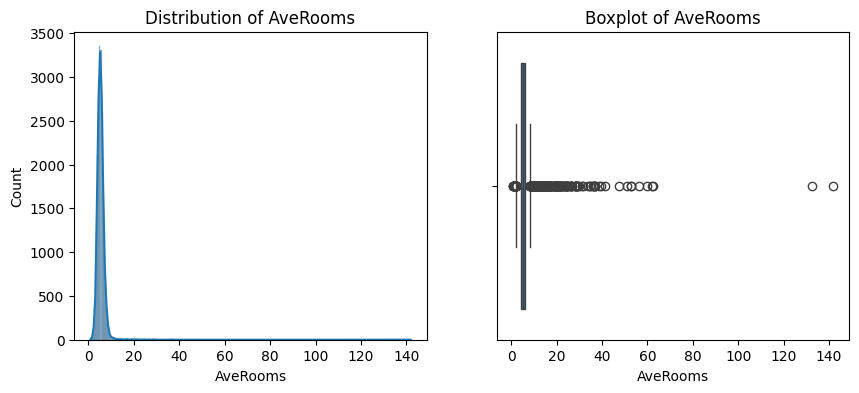

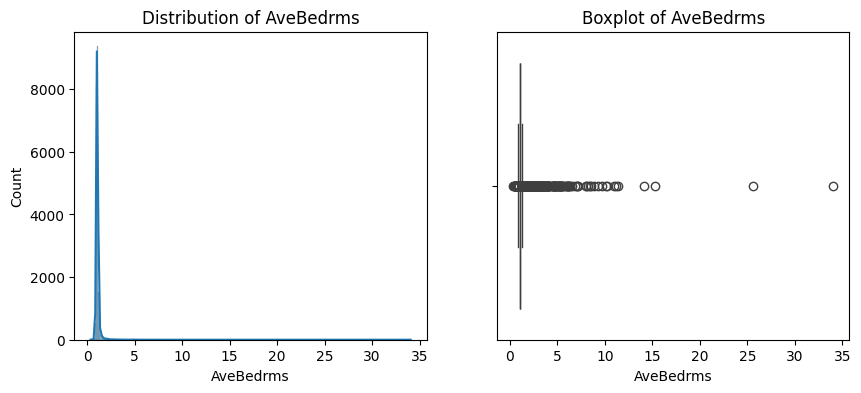

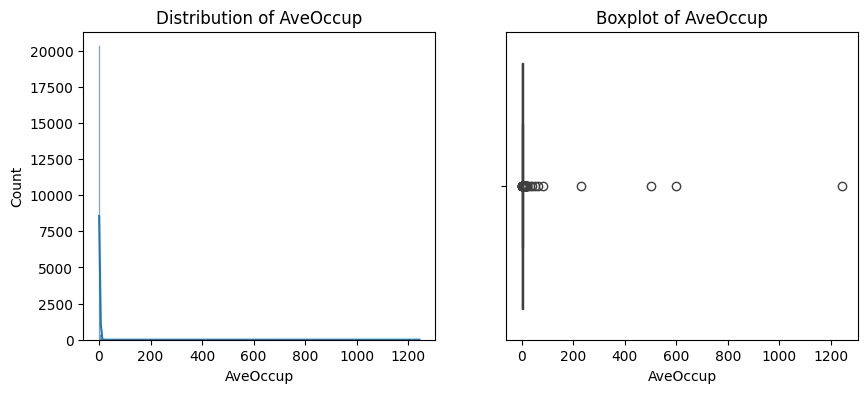

In [8]:
# Melakukan loop untuk mengecek distribusi tiap kolom
for col in columns:
    
    plt.figure(figsize=(10,4))
    
    # plot distribusi
    plt.subplot(1,2,1)
    sns.histplot(df_california[col], kde=True)
    plt.title(f'Distribution of {col}')
    
    # plot boxplot untuk melihat outlier
    plt.subplot(1,2,2)
    sns.boxplot(x=df_california[col])
    plt.title(f'Boxplot of {col}')
    
    plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [9]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [10]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
# menentukan fitur (X) dan target (y)
X = df_california.drop('house_price', axis=1)
y = df_california['house_price']

# splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Jumlah data train:", X_train.shape)
print("Jumlah data test:", X_test.shape)



Jumlah data train: (16512, 8)
Jumlah data test: (4128, 8)


## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [11]:
# 1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?

# membaca dataset
df_company = pd.read_csv('company.csv')

# cek jumlah missing value
missing = df_company['Headquarters'].isnull().sum()

# total data
total = len(df_company)

# persentase missing value
persentase = (missing / total) * 100

print("Jumlah missing value:", missing)
print("Persentase missing value:", persentase, "%")


Jumlah missing value: 0
Persentase missing value: 0.0 %


In [12]:
#Tulis jawaban missing value handling kolom Headquarters disini

#jawaban
#Berdasarkan hasil pengecekan pada kolom Headquarters di dataset company.csv, ditemukan bahwa jumlah missing value adalah 0 dengan persentase 0%.
#Tipe data pada kolom Headquarters adalah string (kategorik). Berdasarkan aturan missing value handling, data kategorik biasanya ditangani menggunakan modus (mode).
#Namun karena tidak terdapat missing value pada kolom tersebut, maka kolom Headquarters tidak perlu di-drop maupun dilakukan proses handling missing value.



In [13]:
df_company['Headquarters'].dtype


<StringDtype(storage='python', na_value=nan)>

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [14]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')


In [15]:
#Splitting terlebih dahulu
from sklearn.model_selection import train_test_split

# menentukan fitur (X) dan target (y)
X = df_churn.drop('Churn', axis=1)
y = df_churn['Churn']

# splitting data 80% train dan 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Jumlah data train:", X_train.shape)
print("Jumlah data test:", X_test.shape)


Jumlah data train: (5634, 20)
Jumlah data test: (1409, 20)


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [16]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder
# membaca dataset
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

# memilih kolom yang akan di-encode
cols = ['StreamingMovies', 'StreamingTV', 'TechSupport', 
        'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']


In [17]:
# mengganti nilai "No internet service" menjadi "No"
for col in cols:
    df_churn[col] = df_churn[col].replace('No internet service', 'No')

# validasi perubahan
for col in cols:
    print("Value counts untuk", col)
    print(df_churn[col].value_counts())
    print("----------------------")

Value counts untuk StreamingMovies
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64
----------------------
Value counts untuk StreamingTV
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64
----------------------
Value counts untuk TechSupport
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64
----------------------
Value counts untuk DeviceProtection
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64
----------------------
Value counts untuk OnlineBackup
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
----------------------
Value counts untuk OnlineSecurity
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
----------------------
Value counts untuk MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
----------------------


In [18]:
# melakukan label encoding
le = LabelEncoder()

for col in cols:
    df_churn[col] = le.fit_transform(df_churn[col])

In [19]:
# melihat hasil encoding
df_churn[cols].head()

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
0,0,0,0,0,1,0,1
1,0,0,0,1,0,1,0
2,0,0,0,0,1,1,0
3,0,0,1,1,0,1,1
4,0,0,0,0,0,0,0


## Selesai :)